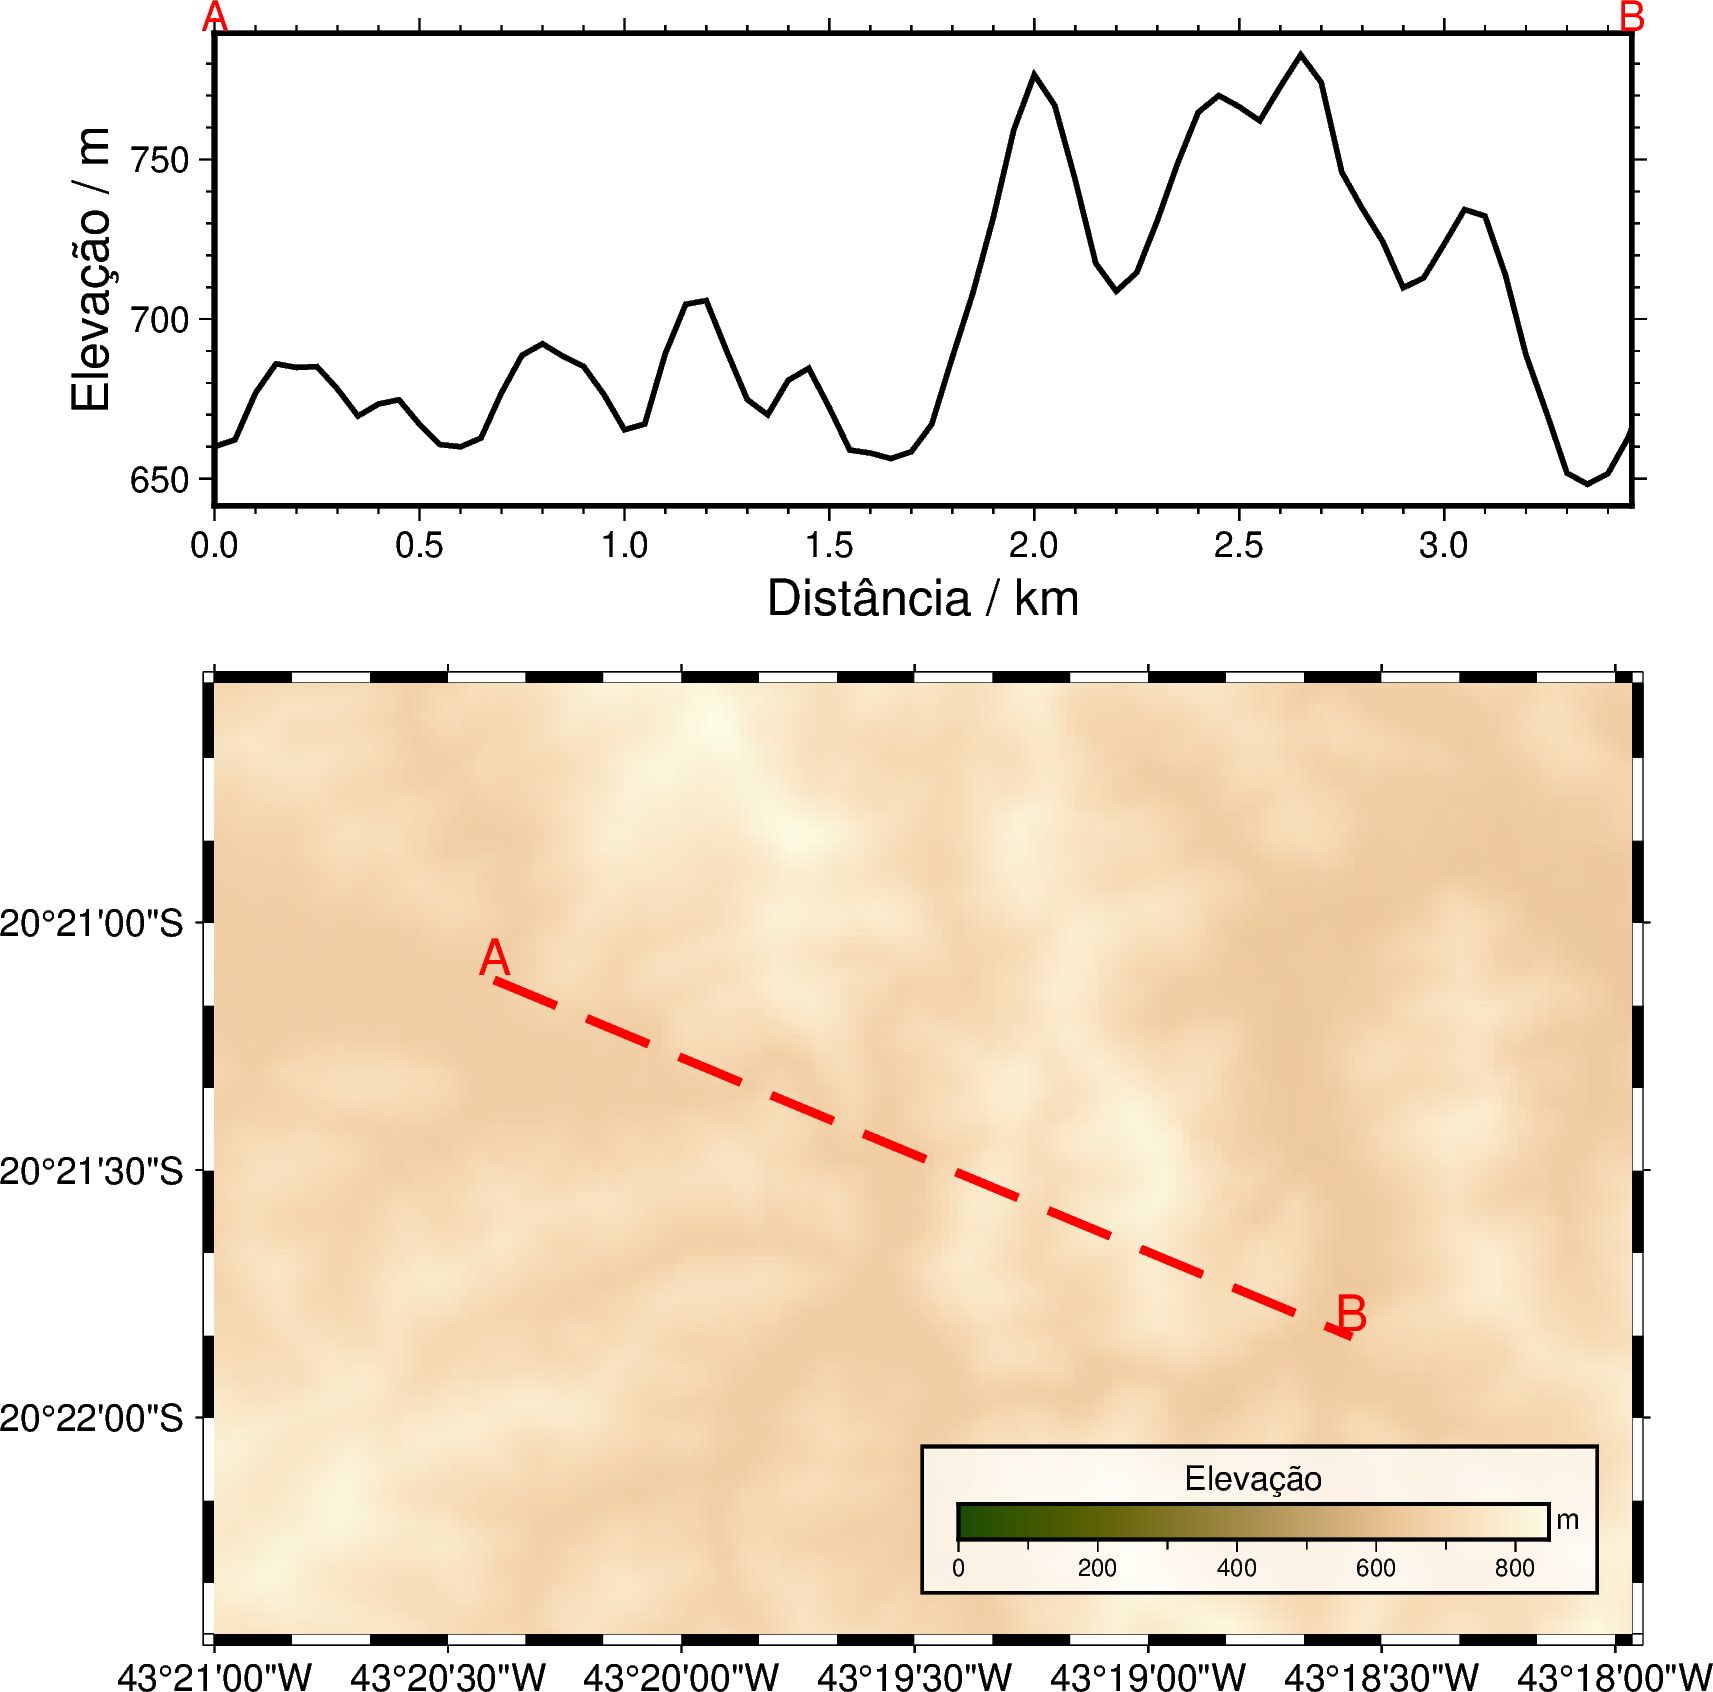

In [42]:
import pygmt

# ------------------------------------------
# Coordenadas do perfil (A -> B)
# 20.3735°S, 43.34406°W : 20.33757°S, 43.29856°W
lonA, latA = -43.34000090983903419, -20.35193810924424795
lonB, latB = -43.30940394775463176, -20.36394659436339438
# -43.34000090983903419 -20.35193810924424795,
# -43.34000090983903419 -20.35193810924424795,
# -43.30940394775463176 -20.36394659436339438

# Pequena margem em torno da linha para o mapa
margin = 0.01
region_map = [
    min(lonA, lonB) - margin,
    max(lonA, lonB) + margin,
    min(latA, latB) - margin,
    max(latA, latB) + margin,
]

fig = pygmt.Figure()

# ==========================================
# Painel inferior: mapa de relevo + linha A–B
# ==========================================

fig.basemap(
    region=region_map,
    projection="M12c",         # mapa ~12 cm de largura
    frame=["WSen", "af"],
)

# Relevo para a região
grid_map = pygmt.datasets.load_earth_relief(
    resolution="01s",          # mais detalhado que 1m (1 arc-min)
    region=region_map,
)

fig.grdimage(grid=grid_map, cmap="oleron")

fig.colorbar(
    position="jBR+o0.7c/0.8c+h+w5c/0.3c+ml",
    box="+gwhite@30+p0.8p,black",
    frame=["x+lElevação", "y+lm"],
    
)

# Linha de perfil A–B no mapa
fig.plot(
    x=[lonA, lonB],
    y=[latA, latB],
    pen="2p,red,dashed",
)

fig.text(
    x=[lonA, lonB],
    y=[latA, latB],
    text=["A", "B"],
    offset="0c/0.2c",
    font="12p,red",
)

# ==========================================
# Painel superior: perfil topográfico
# ==========================================

# Sobe a origem do próximo plot
fig.shift_origin(yshift="h+1.5c")

# Pontos ao longo da linha A–B
track_df = pygmt.project(
    center=[lonA, latA],
    endpoint=[lonB, latB],
    generate="0.05",  # passo ao longo da linha
    unit=True,       # 'p' em quilômetros
)

# Amostra o relevo ao longo do perfil
track_df = pygmt.grdtrack(
    grid=grid_map,
    points=track_df,
    newcolname="elevation",
)

dist = track_df["p"]          # distância ao longo do perfil (km)
elev = track_df["elevation"]  # elevação (m)

# Define limites verticais com uma folga
zmin, zmax = float(elev.min()), float(elev.max())
dz = 0.05 * (zmax - zmin) if zmax > zmin else 50.0
region_profile = [0, float(dist.max()), zmin - dz, zmax + dz]

fig.basemap(
    region=region_profile,
    projection="X12c/4c",
    frame=["WSen", "xaf+lDistância / km", "yaf+lElevação / m"],
)

fig.plot(
    x=dist,
    y=elev,
    pen="1.2p,black",
)

# Rótulos A e B no topo do perfil
fig.text(
    x=[dist.iloc[0], dist.iloc[-1]],
    y=[region_profile[3], region_profile[3]],
    text=["A", "B"],
    no_clip=True,
    font="10p,red",
    offset="0c/0.15c",
)

# Para visualizar na tela
fig.show()

# Se quiser abrir no QGIS como raster, salve como PNG e depois adicione no QGIS:
# fig.savefig("perfil_mapa_AB.png", dpi=300)
